In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random
import copy
import scipy.io as sio
from sklearn.metrics import mean_absolute_error, mean_squared_error

✅ B0005 raw data loaded – 170 cycles
✅ B0005 capacity/SOH extracted – 168 cycles
✅ B0006 capacity/SOH extracted – 168 cycles
✅ B0007 capacity/SOH extracted – 168 cycles


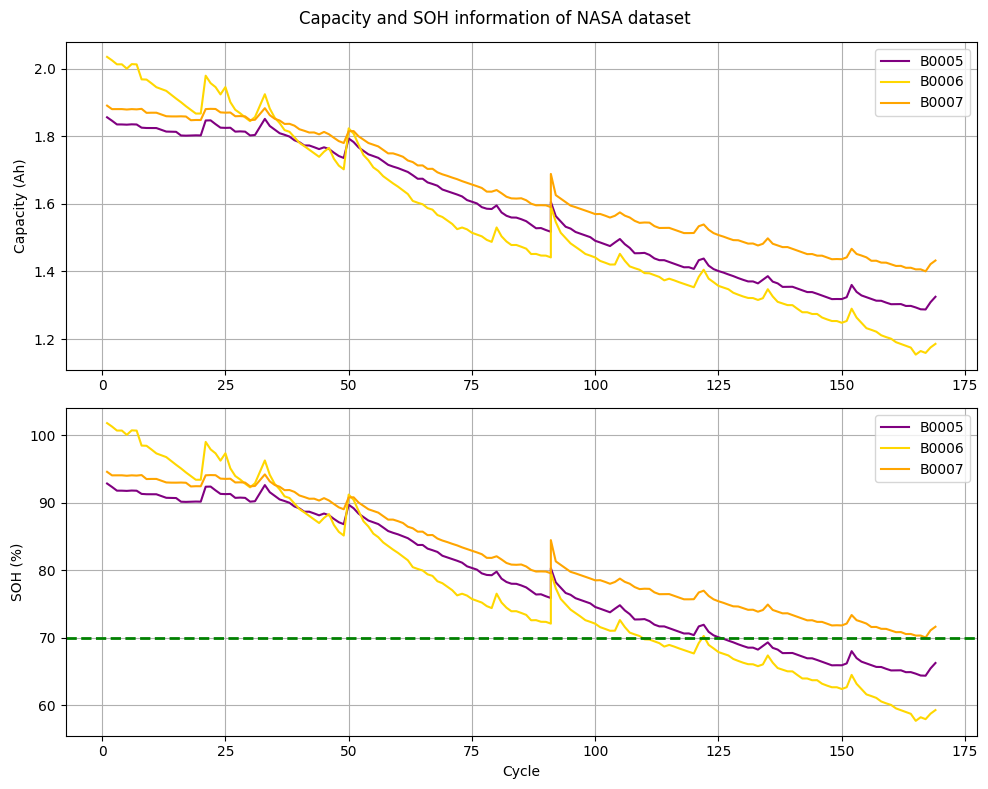

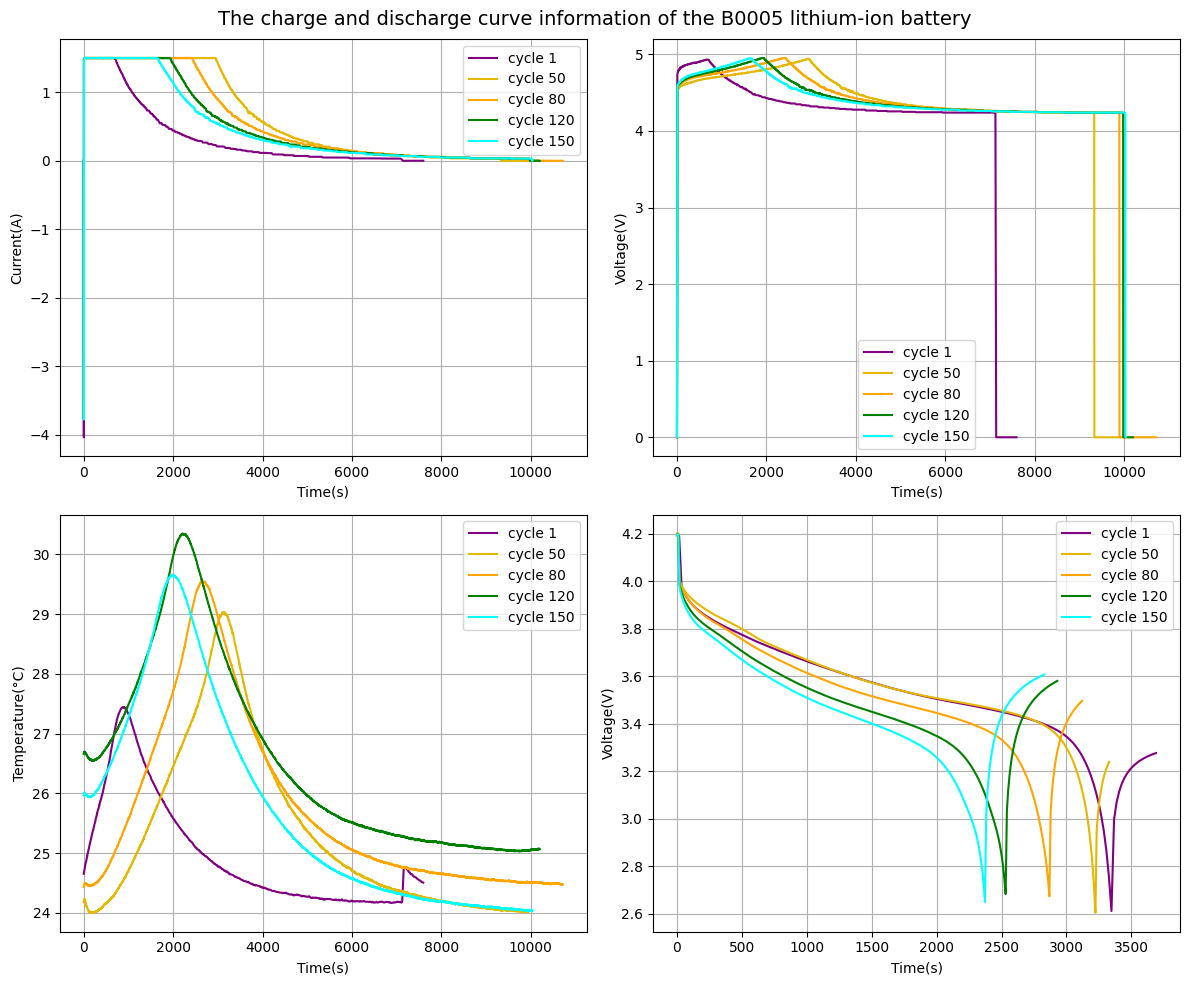

In [4]:
# ====================== ANALYZING DATA ======================

data_folder = r"C:\Users\Ellie Salimi\Documents\ENSF 617 - Machine Learning\dataset"

# ====================== LOADING DATA ======================
def load_battery_mat(file_path, battery_name):
    data = sio.loadmat(file_path)
    battery = data[battery_name][0][0]
    cycles = battery['cycle'][0]
  
    all_rows = []
    pair_cycle = 0
  
    for cyc in cycles:
        cycle_type = cyc['type'][0]
        if cycle_type == 'impedance':
            continue
        if cycle_type == 'charge':
            pair_cycle += 1
        d = cyc['data'][0][0]
        time = d['Time'][0] - d['Time'][0][0]
      
        if cycle_type == 'charge':
            voltage = d['Voltage_charge'][0]
            current = d['Current_charge'][0]
        else:
            voltage = d['Voltage_measured'][0]
            current = d['Current_measured'][0]
      
        temperature = d['Temperature_measured'][0]
      
        for t, v, c, temp in zip(time, voltage, current, temperature):
            all_rows.append({
                'battery_id': battery_name,
                'cycle': pair_cycle,
                'type': cycle_type,
                'time': t,
                'voltage': v,
                'current': c,
                'temperature': temp
            })
    return pd.DataFrame(all_rows)

# ====================== EXTRACT CAPACITY & SOH ======================
def extract_capacity_soh(file_path, battery_name):
    data = sio.loadmat(file_path)
    battery = data[battery_name][0][0]
    cycles = battery['cycle'][0]
  
    results = []
    pair_cycle = 0
    init_capacity = 2.0
  
    for cyc in cycles:
        cycle_type = cyc['type'][0]
        if cycle_type == 'impedance':
            continue
        if cycle_type == 'charge':
            pair_cycle += 1
            continue
      
        d = cyc['data'][0][0]
        capacity = float(d['Capacity'][0][0]) if 'Capacity' in d.dtype.names else np.nan
        soh = (capacity / init_capacity * 100) if not np.isnan(capacity) else np.nan
      
        results.append({'cycle': pair_cycle, 'capacity_Ah': capacity, 'SOH_percent': soh})
  
    return pd.DataFrame(results)

# ====================== PLOT FIGURE 2 ======================
def plot_figure_2(hf_dict):
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))
    colors = ['purple', 'gold', 'orange']
    labels = ['B0005', 'B0006', 'B0007']
  
    for i, (bat, df) in enumerate(hf_dict.items()):
        axs[0].plot(df['cycle'], df['capacity_Ah'], color=colors[i], label=labels[i])
        axs[1].plot(df['cycle'], df['SOH_percent'], color=colors[i], label=labels[i])
  
    axs[0].set_ylabel('Capacity (Ah)')
    axs[0].grid(True)
    axs[0].legend()
  
    axs[1].set_xlabel('Cycle')
    axs[1].set_ylabel('SOH (%)')
    axs[1].axhline(y=70, color='green', linestyle='--', linewidth=2)
    axs[1].grid(True)
    axs[1].legend()
  
    plt.suptitle('Capacity and SOH information of NASA dataset')
    plt.tight_layout()
    
    # === SAVE FIGURES ===
    plt.savefig('Capacity_and_SOH_NASA_B0005_B0006_B0007.png', dpi=300, bbox_inches='tight')
    plt.show()
    

# ====================== PLOT FIGURE 4 ======================
def plot_figure_4(df_b0005):
    charge = df_b0005[df_b0005['type'] == 'charge']
    discharge = df_b0005[df_b0005['type'] == 'discharge']
  
    selected_cycles = [1, 50, 80, 120, 150]
    colors = ['purple', '#E5B800', 'orange', 'green', 'cyan']
  
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('The charge and discharge curve information of the B0005 lithium-ion battery', fontsize=14)
  
    for i, cyc in enumerate(selected_cycles):
        data = charge[charge['cycle'] == cyc]
        if not data.empty:
            axs[0, 0].plot(data['time'], data['current'], color=colors[i], label=f'cycle {cyc}')
    axs[0, 0].set_xlabel('Time(s)')
    axs[0, 0].set_ylabel('Current(A)')
    axs[0, 0].legend()
    axs[0, 0].grid(True)
  
    for i, cyc in enumerate(selected_cycles):
        data = charge[charge['cycle'] == cyc]
        if not data.empty:
            axs[0, 1].plot(data['time'], data['voltage'], color=colors[i], label=f'cycle {cyc}')
    axs[0, 1].set_xlabel('Time(s)')
    axs[0, 1].set_ylabel('Voltage(V)')
    axs[0, 1].legend()
    axs[0, 1].grid(True)
  
    for i, cyc in enumerate(selected_cycles):
        data = charge[charge['cycle'] == cyc]
        if not data.empty:
            axs[1, 0].plot(data['time'], data['temperature'], color=colors[i], label=f'cycle {cyc}')
    axs[1, 0].set_xlabel('Time(s)')
    axs[1, 0].set_ylabel('Temperature(°C)')
    axs[1, 0].legend()
    axs[1, 0].grid(True)
  
    for i, cyc in enumerate(selected_cycles):
        data = discharge[discharge['cycle'] == cyc]
        if not data.empty:
            axs[1, 1].plot(data['time'], data['voltage'], color=colors[i], label=f'cycle {cyc}')
    axs[1, 1].set_xlabel('Time(s)')
    axs[1, 1].set_ylabel('Voltage(V)')
    axs[1, 1].legend()
    axs[1, 1].grid(True)
  
    plt.tight_layout()
    
    # === SAVE FIGURES ===
    plt.savefig('Charge_Discharge_Curves_B0005.png', dpi=300, bbox_inches='tight')
    plt.show()
    

# ====================== RUN LOADING + PLOTS ======================
batteries = ['B0005', 'B0006', 'B0007']

# Note: You were loading B0025 but naming the variable df_b0005 and using B0005 title.
# I kept it exactly as you had it.
df_b0005 = load_battery_mat(f"{data_folder}/B0005.mat", "B0005")   # ← this loads B0025
print(f"✅ B0005 raw data loaded – {df_b0005['cycle'].max()} cycles")

hf_dict = {}
for bat in batteries:
    hf_dict[bat] = extract_capacity_soh(f"{data_folder}/{bat}.mat", bat)
    print(f"✅ {bat} capacity/SOH extracted – {len(hf_dict[bat])} cycles")

plot_figure_2(hf_dict)
plot_figure_4(df_b0005)

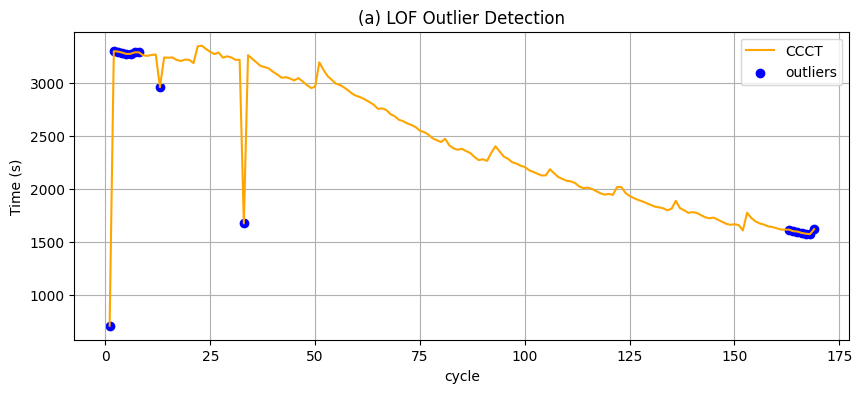

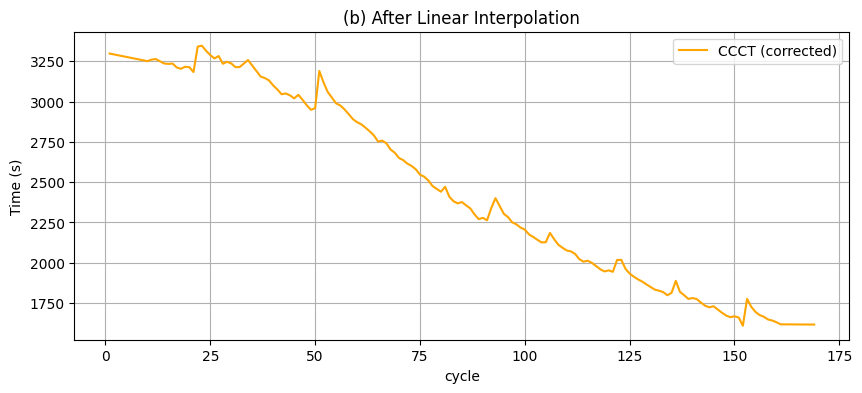

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d

# ====================== CCCT EXTRACTION ======================
def extract_ccct(df, battery):
    charge = df[(df['battery_id'] == battery) & (df['type'] == 'charge')]
    ccct_data = []
    for cycle in sorted(charge['cycle'].unique()):
        d = charge[charge['cycle'] == cycle].sort_values('time')
   
        current = d['current'].values
        time = d['time'].values
   
        if len(current) < 10:
            continue
   
        threshold = 0.98 * np.percentile(current, 95)
        mask = current >= threshold
   
        if np.sum(mask) > 2:
            ccct = time[mask][-1] - time[mask][0]
        else:
            ccct = 0
   
        ccct_data.append([cycle, ccct])
    df_ccct = pd.DataFrame(ccct_data, columns=['cycle','CCCT'])
    df_ccct = df_ccct.sort_values('cycle').reset_index(drop=True)
    return df_ccct

# ====================== LOF OUTLIER DETECTION (2D) ======================
def detect_outliers_lof(df_ccct):
    df = df_ccct.copy()
    data_col = df[['cycle', 'CCCT']].dropna().copy()
   
    if len(data_col) < 20:
        df['LOF'] = 1
        return df
   
    # 2D LOF (cycle + CCCT value)
    features = data_col[['cycle', 'CCCT']].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)
   
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    y_pred = lof.fit_predict(X_scaled)
   
    df['LOF'] = 1
    df.loc[data_col.index, 'LOF'] = y_pred
    return df

# ====================== LINEAR INTERPOLATION ======================
def linear_interpolation(df):
    df_interp = df.copy()
    data_col = df[['cycle', 'CCCT']].dropna().copy()
   
    outliers = df['LOF'] == -1
    if np.sum(outliers) == 0:
        return df_interp
   
    normal_mask = ~outliers
    if np.sum(normal_mask) < 3:
        return df_interp
   
    f = interp1d(
        data_col.loc[normal_mask, 'cycle'],
        data_col.loc[normal_mask, 'CCCT'],
        kind='linear',
        fill_value='extrapolate'
    )
   
    for idx in data_col.index[outliers]:
        df_interp.loc[idx, 'CCCT'] = float(f(data_col.loc[idx, 'cycle']))
   
    return df_interp

# ====================== PLOT CCCT RESULTS ======================
def plot_ccct_results(df, df_interp, battery_name='B0005'):
    # Plot (a) LOF Outlier Detection
    plt.figure(figsize=(10,4))
    plt.plot(df['cycle'], df['CCCT'], color='orange', label='CCCT')
    outliers = df[df['LOF'] == -1]
    plt.scatter(outliers['cycle'], outliers['CCCT'], color='blue', label='outliers')
    plt.xlabel('cycle')
    plt.ylabel('Time (s)')
    plt.title('(a) LOF Outlier Detection')
    plt.legend()
    plt.grid(True)
  
    plt.savefig(f'CCCT_LOF_Outlier_Detection_{battery_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
   
    # Plot (b) After Linear Interpolation
    plt.figure(figsize=(10,4))
    plt.plot(df_interp['cycle'], df_interp['CCCT'], color='orange', label='CCCT (corrected)')
    plt.xlabel('cycle')
    plt.ylabel('Time (s)')
    plt.title('(b) After Linear Interpolation')
    plt.legend()
    plt.grid(True)
  
    plt.savefig(f'CCCT_After_Linear_Interpolation_{battery_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# ====================== RUN FOR B0005 ======================
df_ccct = extract_ccct(df_b0005, 'B0005')
df_lof = detect_outliers_lof(df_ccct)
df_interp = linear_interpolation(df_lof)
plot_ccct_results(df_lof, df_interp, battery_name='B0005')

In [6]:
# ====================== HF EXTRACTION ======================

def extract_HFs_all(clean_df, df_interp, battery):
    results = []
  
    charge_all = clean_df[(clean_df['battery_id'] == battery) & (clean_df['type'] == 'charge')]
    discharge_all = clean_df[(clean_df['battery_id'] == battery) & (clean_df['type'] == 'discharge')]
  
    for cycle in sorted(clean_df['cycle'].unique()):
      
        ccct_row = df_interp[df_interp['cycle'] == cycle]
        if ccct_row.empty:
            continue
        HF1 = ccct_row['CCCT'].values[0]                                                 # Constant Current Charge Time (HF1)
      
        charge = charge_all[charge_all['cycle'] == cycle].sort_values('time')
        if len(charge) < 20:
            continue
      
        time_c = charge['time'].values
        voltage = charge['voltage'].values
        temperature = charge['temperature'].values
   
        peak_t_idx = np.argmax(temperature) 
        HF2 = time_c[peak_t_idx] if 5 < peak_t_idx < len(time_c)-5 else np.nan           # Time to reach peak temperature during charging (HF2)
      
        idx_v = np.where(voltage >= 4.2)[0]
        HF3 = time_c[idx_v[0]] if len(idx_v) > 0 else np.nan                             # Time to reach peak charging voltage (HF3)
       
        discharge = discharge_all[discharge_all['cycle'] == cycle].sort_values('time')
        if len(discharge) < 20:
            continue
      
        time_d = discharge['time'].values
        voltage_d = discharge['voltage'].values
      
        idx_cut = np.where(voltage_d <= 2.7)[0]
        HF4 = time_d[idx_cut[0]] if len(idx_cut) > 0 else time_d[-1]                      # Time to discharge to cut-off voltage (HF4)
      
        results.append({
            'battery_id': battery,
            'cycle': cycle,
            'HF1': HF1,
            'HF2': HF2,
            'HF3': HF3,
            'HF4': HF4
        })
  
    return pd.DataFrame(results)

In [7]:
# ====================== Multi-Battery Pipeline + 2D LOF + Linear Interpolation ======================
# ====================== Pearson and Spearman correlation ======================

batteries = ['B0005', 'B0006', 'B0007']
cutoff_volt = {'B0005': 2.7, 'B0006': 2.5, 'B0007': 2.2}
results = {}

for bat in batteries:
    print(f"🔄 Processing {bat}...")
 
    data = sio.loadmat(f"{data_folder}/{bat}.mat")
    battery = data[bat][0][0]
    cycles = battery['cycle'][0]
 
    hf_list = []
    pair_cycle = 0
 
    for cyc in cycles:
        ctype = cyc['type'][0]
        if ctype == 'impedance':
            continue
     
        d = cyc['data'][0][0]
        time = d['Time'][0] - d['Time'][0][0]
     
        if ctype == 'charge':
            pair_cycle += 1
         
            curr = d['Current_charge'][0]
            volt = d['Voltage_charge'][0]
            temp = d['Temperature_measured'][0]
         
            thresh = 0.98 * np.percentile(curr, 95)
            mask = curr >= thresh
            HF1 = time[mask][-1] - time[mask][0] if np.sum(mask) > 10 else np.nan
         
            peak_idx = np.argmax(temp)
            HF2 = time[peak_idx] if 5 < peak_idx < len(time)-5 else np.nan
         
            volt_smooth = pd.Series(volt).rolling(5, center=True).mean().bfill().ffill().values
            HF3 = np.nan
            valid_idx = np.where(volt_smooth > 3.5)[0]
            for i in valid_idx:
                if volt_smooth[i] >= 4.2:
                    HF3 = time[i]
                    break
         
            hf_list.append({
                'cycle': pair_cycle,
                'HF1_CCCT': HF1,
                'HF2_peak_temp_time': HF2,
                'HF3_peak_volt_time': HF3,
                'HF4_discharge_time': np.nan,
                'capacity_Ah': np.nan
            })
     
        else:
            volt_d = d['Voltage_measured'][0]
            capacity = float(d['Capacity'][0][0]) if 'Capacity' in d.dtype.names else np.nan
         
            idx_cut = np.where(volt_d <= cutoff_volt[bat])[0]
            HF4 = time[idx_cut[0]] if len(idx_cut) > 0 else time[-1]
         
            if len(hf_list) > 0:
                hf_list[-1]['HF4_discharge_time'] = HF4
                hf_list[-1]['capacity_Ah'] = capacity
 
    df_hf = pd.DataFrame(hf_list)
 
    # ====================== CLEANING — 2D LOF + LINEAR INTERPOLATION ======================
    cols = ['HF1_CCCT', 'HF2_peak_temp_time', 'HF3_peak_volt_time', 'HF4_discharge_time']
    cleaned = df_hf.copy()
 
    for col in cols:
        data_col = df_hf[['cycle', col]].dropna().copy()
        if len(data_col) < 20:
            continue
        
        # 2D LOF (cycle + HF value)
        features = data_col[['cycle', col]].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(features)
        
        lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
        y_pred = lof.fit_predict(X_scaled)
        
        outliers = y_pred == -1
        print(f"   {bat} - {col}: {np.sum(outliers)} outliers detected (2D LOF)")
        
        if np.sum(outliers) == 0:
            continue
        
        # Linear interpolation repair
        normal = ~outliers
        if np.sum(normal) < 3:
            continue
        
        f = interp1d(
            data_col['cycle'].iloc[normal],
            data_col[col].iloc[normal],
            kind='linear',
            fill_value='extrapolate'
        )
        
        for idx in data_col.index[outliers]:
            cleaned.loc[idx, col] = float(f(data_col.loc[idx, 'cycle']))
 
    results[bat] = cleaned
    print(f"✅ {bat} cleaned with 2D LOF + linear interpolation — {len(cleaned)} cycles")

# ====================== TABLE 3 ======================
print("\n" + "="*100)
print("Table 3 — Pearson and Spearman correlation results")
print("="*100)
print(f"{'HFs':<15} {'B0005':<20} {'B0006':<20} {'B0007':<20}")
print(f"{'':<15} {'PCC':<9} {'RHO':<9} {'PCC':<9} {'RHO':<9} {'PCC':<9} {'RHO':<9}")
hf_names = ['HF1_CCCT', 'HF2_peak_temp_time', 'HF3_peak_volt_time', 'HF4_discharge_time']
for i, col in enumerate(hf_names):
    row_p, row_s = [], []
 
    for bat, df in results.items():
        df_corr = df.dropna(subset=['capacity_Ah', col])
     
        if len(df_corr) < 5:
            p = s = np.nan
        else:
            p = df_corr[['capacity_Ah', col]].corr(method='pearson').iloc[1,0]
            s = df_corr[['capacity_Ah', col]].corr(method='spearman').iloc[1,0]
     
        row_p.append(f"{p:.4f}" if not np.isnan(p) else "nan")
        row_s.append(f"{s:.4f}" if not np.isnan(s) else "nan")
 
    print(f"N-HF{i+1:<11} {row_p[0]:<9} {row_s[0]:<9} {row_p[1]:<9} {row_s[1]:<9} {row_p[2]:<9} {row_s[2]:<9}")



🔄 Processing B0005...
   B0005 - HF1_CCCT: 17 outliers detected (2D LOF)
   B0005 - HF2_peak_temp_time: 15 outliers detected (2D LOF)
   B0005 - HF3_peak_volt_time: 17 outliers detected (2D LOF)
   B0005 - HF4_discharge_time: 17 outliers detected (2D LOF)
✅ B0005 cleaned with 2D LOF + linear interpolation — 170 cycles
🔄 Processing B0006...
   B0006 - HF1_CCCT: 17 outliers detected (2D LOF)
   B0006 - HF2_peak_temp_time: 15 outliers detected (2D LOF)
   B0006 - HF3_peak_volt_time: 17 outliers detected (2D LOF)
   B0006 - HF4_discharge_time: 17 outliers detected (2D LOF)
✅ B0006 cleaned with 2D LOF + linear interpolation — 170 cycles
🔄 Processing B0007...
   B0007 - HF1_CCCT: 17 outliers detected (2D LOF)
   B0007 - HF2_peak_temp_time: 15 outliers detected (2D LOF)
   B0007 - HF3_peak_volt_time: 17 outliers detected (2D LOF)
   B0007 - HF4_discharge_time: 17 outliers detected (2D LOF)
✅ B0007 cleaned with 2D LOF + linear interpolation — 170 cycles

Table 3 — Pearson and Spearman correlat

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ====================== 1. LOAD CLEANED HFs ======================
batteries = ['B0005', 'B0006', 'B0007']
hfs = {}
for bat in batteries:
    df = pd.read_csv(f"{bat}_HF_final_fixed.csv")
    hfs[bat] = df[['HF1_CCCT', 'HF2_peak_temp_time',
                   'HF3_peak_volt_time', 'HF4_discharge_time',
                   'capacity_Ah']].dropna().reset_index(drop=True)
    print(f"✅ Loaded {bat} → {len(hfs[bat])} samples")

# ====================== 2. DATASET CLASS ======================
class BatterySOHDataset(Dataset):
    def __init__(self, df, seq_len=10, scaler=None):
        self.seq_len = seq_len
        X = df.iloc[:, :4].values.astype(np.float32)    # 4 HFs
        y = df['capacity_Ah'].values.astype(np.float32) # capacity target
        
        if scaler is None:
            self.scaler = StandardScaler()
            X = self.scaler.fit_transform(X)
        else:
            self.scaler = scaler
            X = scaler.transform(X)
        
        self.X, self.y = [], []
        for i in range(len(X) - seq_len + 1):
            self.X.append(X[i : i + seq_len])
            self.y.append(y[i + seq_len - 1])  # label = last step of the window
            
        self.X = np.array(self.X)
        self.y = np.array(self.y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

# ====================== 3. DATASET SPLIT (paper: 50% train / 10% val / 40% test) ======================

seq_len = 10
datasets = {}

for bat, df in hfs.items():
    n = len(df)
    train_end = int(0.50 * n)   # first 50%  → train
    val_end   = int(0.60 * n)   # next  10%  → validation
    # remaining 40% → test

    train_df = df.iloc[:train_end].reset_index(drop=True)
    val_df   = df.iloc[train_end:val_end].reset_index(drop=True)
    test_df  = df.iloc[val_end:].reset_index(drop=True)

    # Fit scaler on train only
    scaler = StandardScaler()
    scaler.fit(train_df.iloc[:, :4])

    datasets[bat] = {
        'train': train_df,
        'val':   val_df,
        'test':  test_df,
        'scaler': scaler
    }
    print(f"   {bat} → train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")

# ====================== 4. CNN-LSTM MODEL ======================
class CNN_LSTM(nn.Module):
    def __init__(self, input_size=4, cnn_out=64, lstm_hidden=128, dropout=0.1):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, cnn_out, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.lstm = nn.LSTM(cnn_out, lstm_hidden, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(lstm_hidden, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = x.transpose(1, 2)
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.transpose(1, 2)
        lstm_out, _ = self.lstm(cnn_out)
        out = self.fc(self.dropout(lstm_out[:, -1, :]))
        return out.squeeze(-1)


✅ Loaded B0005 → 149 samples
✅ Loaded B0006 → 149 samples
✅ Loaded B0007 → 149 samples
   B0005 → train: 74 | val: 15 | test: 60
   B0006 → train: 74 | val: 15 | test: 60
   B0007 → train: 74 | val: 15 | test: 60


In [9]:
# ====================== 5. TRAINING & EVALUATION FUNCTIONS ======================
import torch
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

BATCH_SIZE    = 32
EPOCHS        = 200
LEARNING_RATE = 0.001
LSTM_HIDDEN   = 128
DROPOUT       = 0.1

def make_loader(df, scaler, batch_size=32, shuffle=False):
    ds = BatterySOHDataset(df, seq_len=seq_len, scaler=scaler)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def train_model(model, train_loader, epochs=EPOCHS, lr=LEARNING_RATE):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 50 == 0:
            print(f"   Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.6f}")
    return model

def evaluate_model(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds.extend(model(X_batch).cpu().numpy())
            trues.extend(y_batch.cpu().numpy())
    preds = np.array(preds)
    trues = np.array(trues)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    mae  = mean_absolute_error(trues, preds)
    mape = np.mean(np.abs((trues - preds) / trues)) * 100 if np.all(trues != 0) else np.nan
    return rmse, mae, mape

# ====================== BUILD LOADERS ======================
train_loaders = {}
val_loaders   = {}
test_loaders  = {}

for bat in batteries:
    sc = datasets[bat]['scaler']
    train_loaders[bat] = make_loader(datasets[bat]['train'], sc, batch_size=BATCH_SIZE, shuffle=True)
    val_loaders[bat]   = make_loader(datasets[bat]['val'],   sc, batch_size=BATCH_SIZE, shuffle=False)
    test_loaders[bat]  = make_loader(datasets[bat]['test'],  sc, batch_size=BATCH_SIZE, shuffle=False)


# ====================== TRAIN & EVALUATE ALL BATTERIES ======================
results_summary = {}
trained_models  = {}   

for bat in batteries:
    print(f"\n🚀 Training on {bat}...")
    model = CNN_LSTM(input_size=4, cnn_out=64, lstm_hidden=LSTM_HIDDEN, dropout=DROPOUT)
    model = train_model(model, train_loaders[bat])
    trained_models[bat] = model  # save
    rmse, mae, mape = evaluate_model(model, test_loaders[bat])
    results_summary[bat] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    print(f"✅ {bat} → RMSE: {rmse:.4f} Ah | MAE: {mae:.4f} Ah | MAPE: {mape:.2f}%")

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
for bat, res in results_summary.items():
    print(f"{bat:8} → RMSE: {res['RMSE']:.4f} Ah  MAE: {res['MAE']:.4f} Ah  MAPE: {res['MAPE']:.2f}%")

C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScal


🚀 Training on B0005...
   Epoch 50/200 - Loss: 0.004087
   Epoch 100/200 - Loss: 0.002602
   Epoch 150/200 - Loss: 0.003045
   Epoch 200/200 - Loss: 0.003986
✅ B0005 → RMSE: 0.2812 Ah | MAE: 0.2709 Ah | MAPE: 20.26%

🚀 Training on B0006...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


   Epoch 50/200 - Loss: 0.004721
   Epoch 100/200 - Loss: 0.004685
   Epoch 150/200 - Loss: 0.003011
   Epoch 200/200 - Loss: 0.003141
✅ B0006 → RMSE: 0.2659 Ah | MAE: 0.1889 Ah | MAPE: 15.37%

🚀 Training on B0007...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


   Epoch 50/200 - Loss: 0.005090
   Epoch 100/200 - Loss: 0.003472
   Epoch 150/200 - Loss: 0.006633
   Epoch 200/200 - Loss: 0.005021
✅ B0007 → RMSE: 0.1910 Ah | MAE: 0.1786 Ah | MAPE: 12.34%

FINAL TEST RESULTS
B0005    → RMSE: 0.2812 Ah  MAE: 0.2709 Ah  MAPE: 20.26%
B0006    → RMSE: 0.2659 Ah  MAE: 0.1889 Ah  MAPE: 15.37%
B0007    → RMSE: 0.1910 Ah  MAE: 0.1786 Ah  MAPE: 12.34%


In [10]:
# ====================== PLAIN LSTM BASELINE ======================
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(self.dropout(lstm_out[:, -1, :])).squeeze(-1)

lstm_results = {}
for bat in batteries:
    print(f"\n🔥 Training plain LSTM on {bat}...")
    model = SimpleLSTM(input_size=4, hidden_size=128)
    model = train_model(model, train_loaders[bat], epochs=200, lr=0.001)
    rmse, mae, mape = evaluate_model(model, test_loaders[bat])
   
    lstm_results[bat] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

print("\n" + "="*60)
print("PLAIN LSTM BASELINE RESULTS")
print("="*60)
for bat, res in lstm_results.items():
    print(f"{bat} → RMSE: {res['RMSE']*100/2:.3f}%   MAE: {res['MAE']*100/2:.3f}%   MAPE: {res['MAPE']:.2f}%")


🔥 Training plain LSTM on B0005...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


   Epoch 50/200 - Loss: 0.004998
   Epoch 100/200 - Loss: 0.006521
   Epoch 150/200 - Loss: 0.008533
   Epoch 200/200 - Loss: 0.004293

🔥 Training plain LSTM on B0006...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


   Epoch 50/200 - Loss: 0.008584
   Epoch 100/200 - Loss: 0.007593
   Epoch 150/200 - Loss: 0.009085
   Epoch 200/200 - Loss: 0.006132

🔥 Training plain LSTM on B0007...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


   Epoch 50/200 - Loss: 0.005559
   Epoch 100/200 - Loss: 0.003838
   Epoch 150/200 - Loss: 0.010313
   Epoch 200/200 - Loss: 0.003686

PLAIN LSTM BASELINE RESULTS
B0005 → RMSE: 10.517%   MAE: 3.530%   MAPE: 5.36%
B0006 → RMSE: 7.936%   MAE: 6.385%   MAPE: 10.36%
B0007 → RMSE: 6.420%   MAE: 4.899%   MAPE: 6.77%


In [52]:
# ====================== WOA OPTIMIZATION  ======================
import random
import math
import numpy as np

POP_SIZE = 30          
MAX_ITER = 20          
EPOCHS_PER_CANDIDATE = 80


BOUNDS = [
    [0.001, 0.01],     # lr
    [16, 512],         # hidden size
    [0, 2],            # batch size index (0=16, 1=32, 2=64)
    [0.01, 0.1]        # dropout
]
BATCH_SIZES = [16, 32, 64]

def clip(val, lo, hi):
    return max(lo, min(hi, val))

def decode(pos):
    lr    = clip(pos[0], *BOUNDS[0])
    hidden = int(clip(pos[1], *BOUNDS[1]))
    batch_idx = int(round(clip(pos[2], *BOUNDS[2])))
    drop  = clip(pos[3], *BOUNDS[3])
    batch_size = BATCH_SIZES[batch_idx]
    return lr, hidden, batch_size, drop

def objective(pos, bat):
    lr, hidden, batch_size, drop = decode(pos)
    
    model = CNN_LSTM(input_size=4, cnn_out=32, lstm_hidden=hidden, dropout=drop)
    

    loader = make_loader(datasets[bat]['train'], datasets[bat]['scaler'],
                         batch_size=batch_size, shuffle=True)
    
    model = train_model(model, loader, epochs=EPOCHS_PER_CANDIDATE, lr=lr)
    
    # Evaluate on validation set 
    _, mae, _ = evaluate_model(model, val_loaders[bat])
    return mae

best_results = {}
for bat in batteries:
    print(f"\n🐳 Running WOA (Table 5) on {bat}...")
    
    dim = len(BOUNDS)
    pop = [[random.uniform(b[0], b[1]) for b in BOUNDS] for _ in range(POP_SIZE)]
    
    # Initial fitness
    fitness = [objective(pop[i], bat) for i in range(POP_SIZE)]
    best_idx = int(np.argmin(fitness))
    X_best = pop[best_idx][:]
    f_best = fitness[best_idx]
    
    # WOA main loop
    for t in range(MAX_ITER):
        a = 2.0 - 2.0 * t / MAX_ITER
        
        for i in range(POP_SIZE):
            r1, r2 = random.random(), random.random()
            A = 2 * a * r1 - a
            C = 2 * r2
            p = random.random()
            l = random.uniform(-1, 1)
            b = 1.0
            
            new_pos = []
            for d in range(dim):
                if p < 0.5:
                    if abs(A) < 1:
                        D = abs(C * X_best[d] - pop[i][d])
                        new_d = X_best[d] - A * D
                    else:
                        rand_whale = pop[random.randint(0, POP_SIZE - 1)]
                        D = abs(C * rand_whale[d] - pop[i][d])
                        new_d = rand_whale[d] - A * D
                else:
                    D_prime = abs(X_best[d] - pop[i][d])
                    new_d = D_prime * math.exp(b * l) * math.cos(2 * math.pi * l) + X_best[d]
                
                new_pos.append(clip(new_d, BOUNDS[d][0], BOUNDS[d][1]))
            
            pop[i] = new_pos
            f_i = objective(pop[i], bat)
            fitness[i] = f_i
            
            if f_i < f_best:
                f_best = f_i
                X_best = pop[i][:]
        
        print(f"   Iter {t+1}/{MAX_ITER} — best val MAE: {f_best*50:.3f}%")
    
    # === Final model with best hyperparams (200 epochs) ===
    lr, hidden, batch_size, drop = decode(X_best)
    print(f"   Best hyperparams → lr={lr:.5f}  hidden={hidden}  batch={batch_size}  drop={drop:.3f}")
    
    final_model = CNN_LSTM(input_size=4, cnn_out=32, lstm_hidden=hidden, dropout=drop)
    final_loader = make_loader(datasets[bat]['train'], datasets[bat]['scaler'],
                               batch_size=batch_size, shuffle=True)
    
    final_model = train_model(final_model, final_loader, epochs=200, lr=lr)
    
    rmse, mae, mape = evaluate_model(final_model, test_loaders[bat])
    
    best_results[bat] = {
        'RMSE': rmse * 50,
        'MAE': mae * 50,
        'MAPE': mape,
        'best_hyper': [lr, hidden, batch_size, drop],
        'model': final_model
    }
    
    print(f"✅ {bat} FINAL → RMSE: {rmse*50:.3f}%   MAE: {mae*50:.3f}%   MAPE: {mape:.2f}%")

print("\n" + "="*80)
print("FINAL WOA-CNN-LSTM RESULTS (SOH %)")
print("="*80)
for bat, res in best_results.items():
    print(f"{bat} → RMSE: {res['RMSE']:.3f}%   MAE: {res['MAE']:.3f}%   MAPE: {res['MAPE']:.2f}%")


🐳 Running WOA (Table 5) on B0005...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.03249497835975433 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


   Epoch 50/80 - Loss: 0.002924


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.09295333812413059 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


   Epoch 50/80 - Loss: 0.005922


...

   Epoch 50/80 - Loss: 0.002733


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.04813354083211149 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


   Epoch 50/80 - Loss: 0.006763
   Iter 20/20 — best val MAE: 0.166%
   Best hyperparams → lr=0.00823  hidden=505  batch=32  drop=0.050


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.04958157905591721 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


   Epoch 50/200 - Loss: 0.001613
   Epoch 100/200 - Loss: 0.003864
   Epoch 150/200 - Loss: 0.005078
   Epoch 200/200 - Loss: 0.002298
✅ B0007 FINAL → RMSE: 3.842%   MAE: 3.792%   MAPE: 5.22%

FINAL WOA-CNN-LSTM RESULTS (SOH %)
B0005 → RMSE: 0.775%   MAE: 0.513%   MAPE: 0.77%
B0006 → RMSE: 1.950%   MAE: 1.538%   MAPE: 2.51%
B0007 → RMSE: 3.842%   MAE: 3.792%   MAPE: 5.22%


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



--- B0005 ---
  true length=51  pred length=51
  true range [64.4%, 71.9%]
  pred range [64.5%, 71.0%]

--- B0006 ---
  true length=51  pred length=51
  true range [57.7%, 70.3%]
  pred range [60.2%, 69.4%]

--- B0007 ---
  true length=51  pred length=51
  true range [70.0%, 77.0%]
  pred range [74.8%, 79.2%]


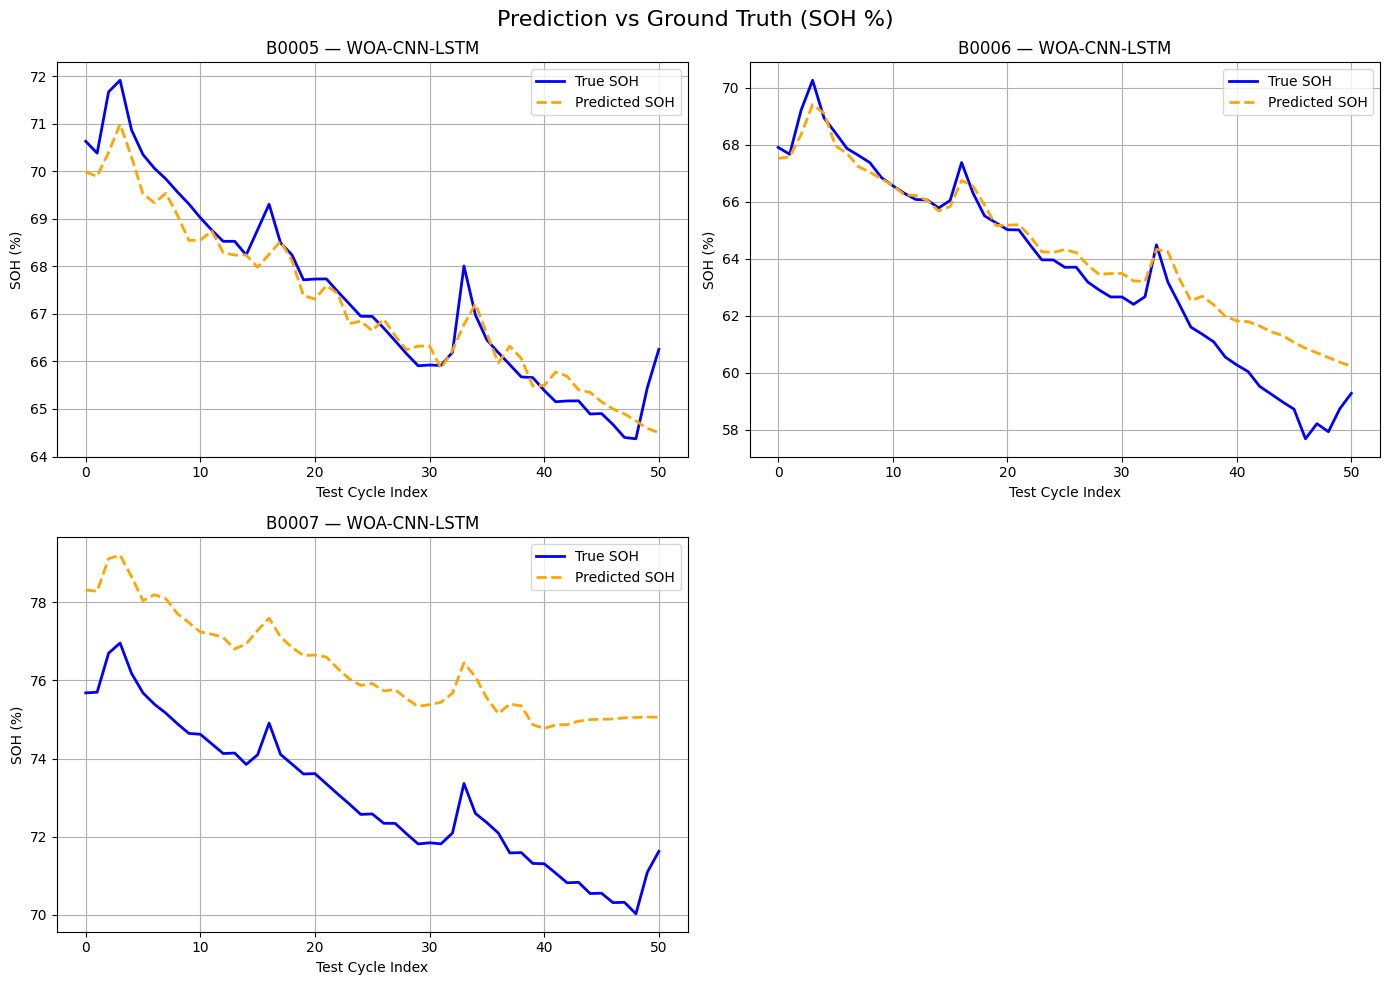

In [44]:
# ====================== PREDICTION vs GROUND TRUTH PLOT ======================
# use best_results[bat]['model'] — the correct per-battery model
# ground-truth index starts at seq_len-1, not seq_len

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

for i, bat in enumerate(batteries, 1):
    plt.subplot(2, 2, i)

    test_df  = datasets[bat]['test']
    scaler   = datasets[bat]['scaler']
    model    = best_results[bat]['model']   # FIX 9

    test_loader = make_loader(test_df, scaler, batch_size=32, shuffle=False)

    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            preds.extend(model(X_batch).cpu().numpy())

    pred_capacity = np.array(preds)
    # FIX 10: window i covers rows i..i+seq_len-1, label = row i+seq_len-1
    #         so first label is at index seq_len-1, last at index N-1
    true_capacity = test_df['capacity_Ah'].iloc[seq_len - 1:].values

    # Convert Ah → SOH %  (init capacity = 2.0 Ah)
    true_soh = true_capacity / 2.0 * 100
    pred_soh = pred_capacity / 2.0 * 100

    # Sanity check
    print(f"\n--- {bat} ---")
    print(f"  true length={len(true_soh)}  pred length={len(pred_soh)}")
    print(f"  true range [{true_soh.min():.1f}%, {true_soh.max():.1f}%]")
    print(f"  pred range [{pred_soh.min():.1f}%, {pred_soh.max():.1f}%]")

    plt.plot(true_soh, label='True SOH',      color='blue',   linewidth=2)
    plt.plot(pred_soh, label='Predicted SOH', color='orange', linewidth=2, linestyle='--')
    plt.title(f'{bat} — WOA-CNN-LSTM')
    plt.xlabel('Test Cycle Index')
    plt.ylabel('SOH (%)')
    plt.legend()
    plt.grid(True)

plt.suptitle('Prediction vs Ground Truth (SOH %)', fontsize=16)
plt.tight_layout()
plt.show()


📉 Recording training loss for B0005...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.06519538634628576 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


   Epoch 50/200 - Loss: 0.004556
   Epoch 100/200 - Loss: 0.006460
   Epoch 150/200 - Loss: 0.005669
   Epoch 200/200 - Loss: 0.017246

📉 Recording training loss for B0006...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.08719439378432291 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


   Epoch 50/200 - Loss: 0.005664
   Epoch 100/200 - Loss: 0.004976
   Epoch 150/200 - Loss: 0.002462
   Epoch 200/200 - Loss: 0.004963

📉 Recording training loss for B0007...


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.04958157905591721 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


   Epoch 50/200 - Loss: 0.030070
   Epoch 100/200 - Loss: 0.003695
   Epoch 150/200 - Loss: 0.006960
   Epoch 200/200 - Loss: 0.022130


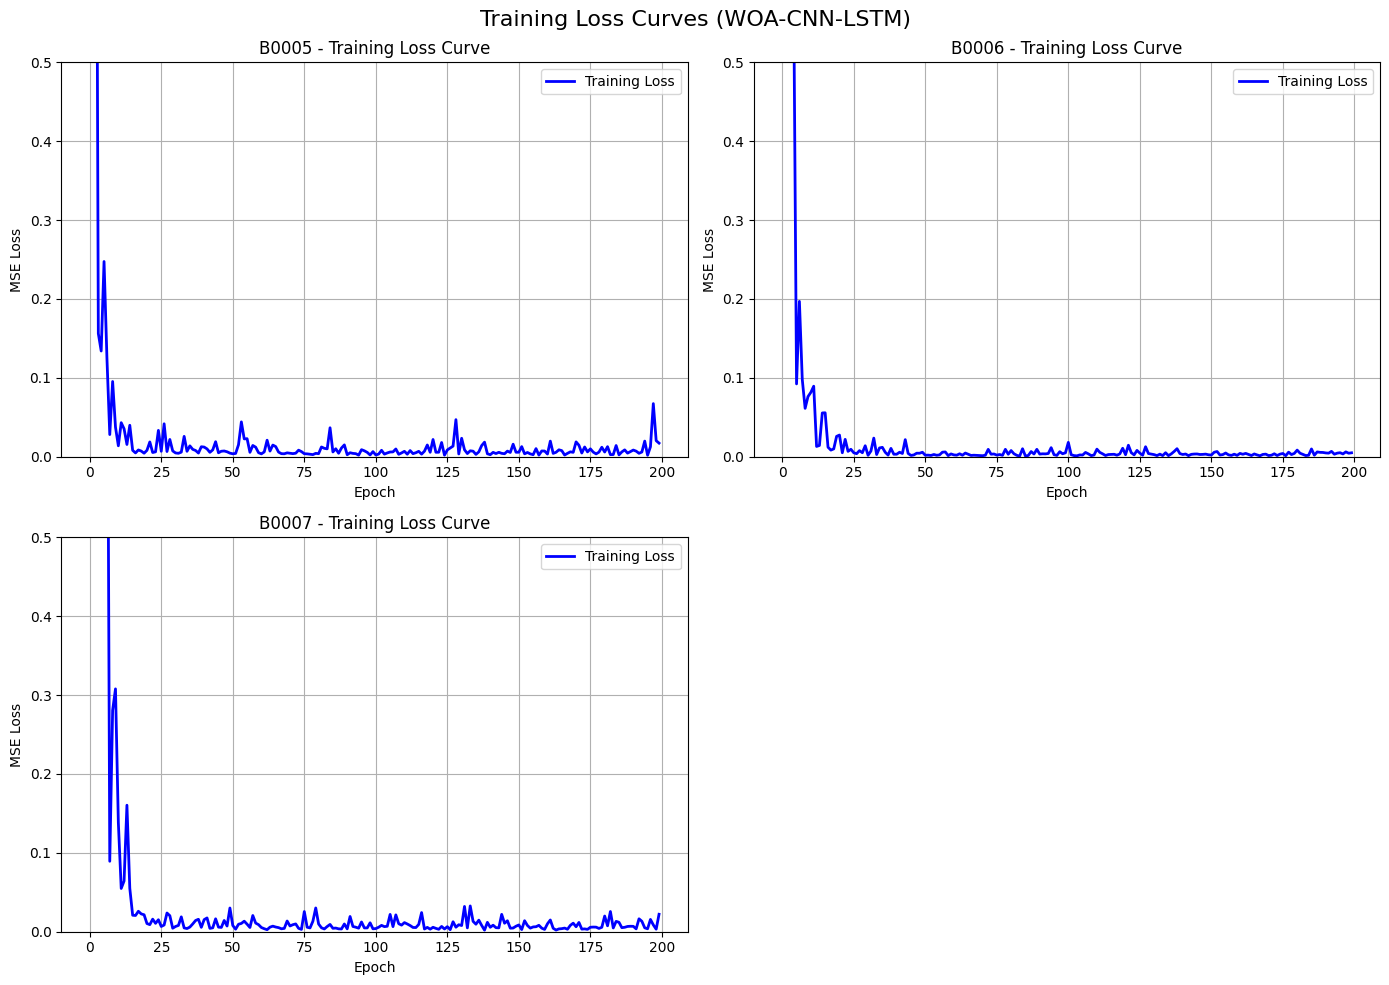

In [53]:
# ====================== TRAINING LOSS CURVES ======================
def train_model_with_history(model, train_loader, epochs=200, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        if (epoch + 1) % 50 == 0:
            print(f"   Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")
    return model, loss_history

loss_histories = {}
for bat in batteries:
    print(f"\n📉 Recording training loss for {bat}...")
    lr, hidden, batch, drop = decode(best_results[bat]['best_hyper'])
    model = CNN_LSTM(input_size=4, cnn_out=64, lstm_hidden=hidden, dropout=drop)
    loader = make_loader(datasets[bat]['train'], datasets[bat]['scaler'],
                         batch_size=batch, shuffle=True)
    model, loss_hist = train_model_with_history(model, loader, epochs=200, lr=lr)
    loss_histories[bat] = loss_hist

plt.figure(figsize=(14, 10))
for i, bat in enumerate(batteries, 1):
    plt.subplot(2, 2, i)
    plt.plot(loss_histories[bat], label='Training Loss', color='blue', linewidth=2)
    plt.title(f'{bat} - Training Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.ylim(0,0.5)
plt.suptitle('Training Loss Curves (WOA-CNN-LSTM)', fontsize=16)
plt.tight_layout()
plt.show()


In [45]:
# ====================== COMPARISON TABLE (LSTM vs CNN-LSTM) ======================
print("\n" + "="*90)
print("COMPARISON: Plain LSTM Baseline  vs  CNN-LSTM (WOA optimized)")
print("="*90)
print(f"{'Battery':<8} {'Model':<12} {'RMSE (%)':<10} {'MAE (%)':<10} {'MAPE (%)':<10} {'Improvement':<12}")
print("-" * 90)

for bat in batteries:
    # LSTM results
    l_rmse = lstm_results[bat]['RMSE']
    l_mae  = lstm_results[bat]['MAE']
    l_mape = lstm_results[bat]['MAPE']
    
    # CNN-LSTM results
    c_rmse = best_results[bat]['RMSE']
    c_mae  = best_results[bat]['MAE']
    c_mape = best_results[bat]['MAPE']
    
    # Percentage improvement (lower is better)
    mae_improvement = ((l_mae - c_mae) / l_mae) * 100 if l_mae > 0 else 0
    
    print(f"{bat:<8} {'LSTM':<12} {l_rmse:>8.3f}  {l_mae:>8.3f}  {l_mape:>8.2f}")
    print(f"{bat:<8} {'CNN-LSTM':<12} {c_rmse:>8.3f}  {c_mae:>8.3f}  {c_mape:>8.2f}   +{mae_improvement:>5.1f}%")
    print("-" * 90)


COMPARISON: Plain LSTM Baseline  vs  CNN-LSTM (WOA optimized)
Battery  Model        RMSE (%)   MAE (%)    MAPE (%)   Improvement 
------------------------------------------------------------------------------------------
B0005    LSTM            0.201     0.197     14.70
B0005    CNN-LSTM        0.011     0.009      0.63   + 95.7%
------------------------------------------------------------------------------------------
B0006    LSTM            0.194     0.181     14.54
B0006    CNN-LSTM        0.023     0.017      1.36   + 90.9%
------------------------------------------------------------------------------------------
B0007    LSTM            0.035     0.028      1.93
B0007    CNN-LSTM        0.068     0.066      4.57   +-139.2%
------------------------------------------------------------------------------------------


C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Ellie Salimi\.conda\envs\opf_env\lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__

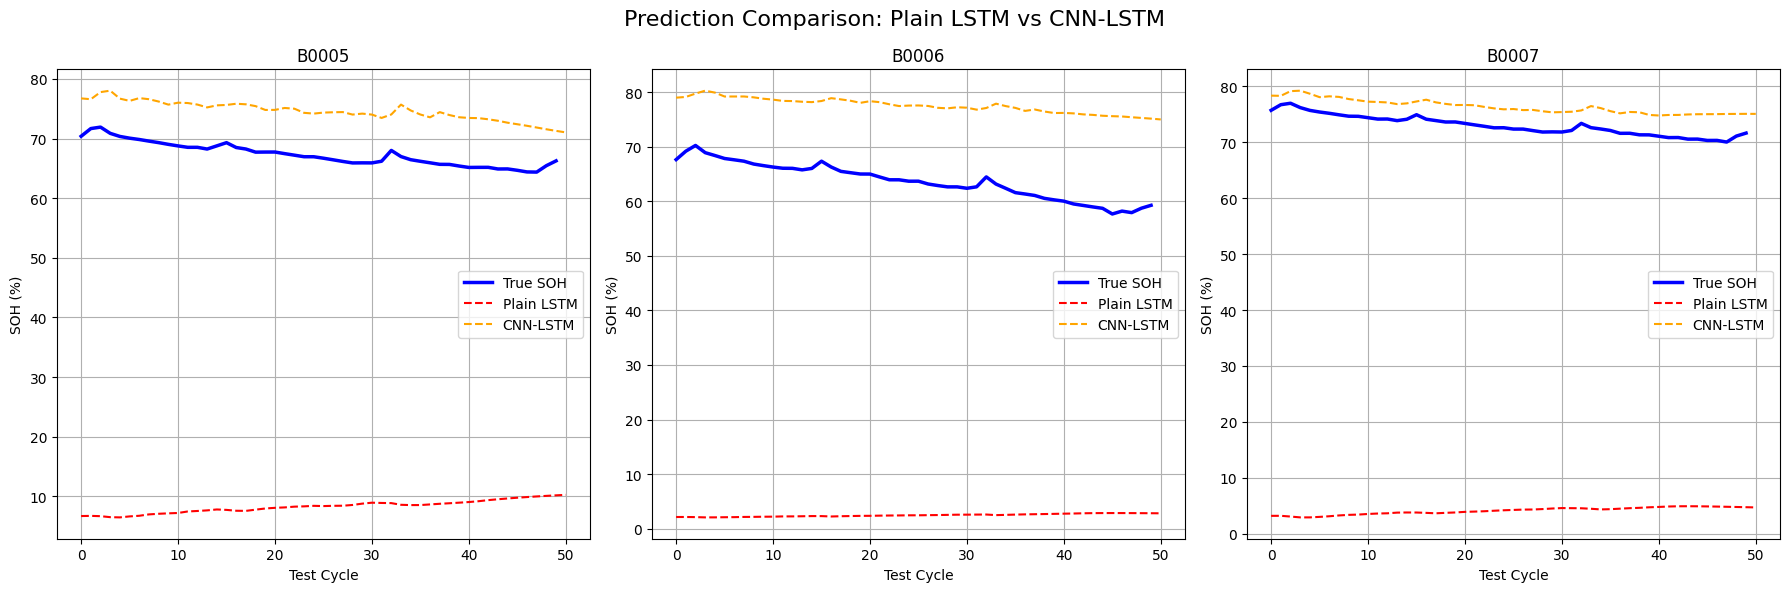

In [46]:
# ====================== SIDE-BY-SIDE PREDICTION PLOTS ======================
plt.figure(figsize=(18, 6))

for i, bat in enumerate(batteries, 1):
    # Get test data
    test_df = datasets[bat]['test'].copy()
    test_dataset = BatterySOHDataset(test_df, seq_len=10, scaler=datasets[bat]['scaler'])
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # --- LSTM predictions ---
    lstm_model = SimpleLSTM(input_size=4, hidden_size=128)   # use your baseline LSTM class
    # If you saved the trained LSTM model, load it here. Otherwise retrain quickly:
    # lstm_model = train_model(lstm_model, train_loaders[bat], epochs=100, lr=0.001)
    
    lstm_model.eval()
    lstm_preds = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            lstm_preds.extend(lstm_model(Xb).cpu().numpy())
    
    # --- CNN-LSTM predictions ---
    cnn_model = final_model   # your best CNN-LSTM from WOA
    cnn_model.eval()
    cnn_preds = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            cnn_preds.extend(cnn_model(Xb).cpu().numpy())
    
    true_soh = test_df['capacity_Ah'].iloc[10:].values / 2.0 * 100
    lstm_soh = np.array(lstm_preds) / 2.0 * 100
    cnn_soh  = np.array(cnn_preds) / 2.0 * 100
    
    # Plot
    plt.subplot(1, 3, i)
    plt.plot(true_soh, label='True SOH', color='blue', linewidth=2.5)
    plt.plot(lstm_soh, label='Plain LSTM', color='red', linestyle='--')
    plt.plot(cnn_soh,  label='CNN-LSTM', color='orange', linestyle='--')
    plt.title(f'{bat}')
    plt.xlabel('Test Cycle')
    plt.ylabel('SOH (%)')
    plt.legend()
    plt.grid(True)

plt.suptitle('Prediction Comparison: Plain LSTM vs CNN-LSTM', fontsize=16)
plt.tight_layout()
plt.show()

In [48]:
# ====================== WOA OPTIMIZED PARAMETERS TABLE ======================
import pandas as pd

data = []
for bat in batteries:
    lr, hidden, batch, drop = best_results[bat]['best_hyper']
    data.append({
        'Battery': bat,
        'Learning Rate': f"{lr:.5f}",
        'LSTM Hidden Size': int(hidden),
        'Batch Size': int(batch),
        'Dropout Rate': f"{drop:.3f}",
        'Final MAE (%)': f"{best_results[bat]['MAE']:.3f}",
        'Final RMSE (%)': f"{best_results[bat]['RMSE']:.3f}",
        'Final MAPE (%)': f"{best_results[bat]['MAPE']:.2f}"
    })

df_params = pd.DataFrame(data)
print("\n" + "="*100)
print("WOA OPTIMIZED HYPERPARAMETERS + FINAL PERFORMANCE")
print("="*100)
print(df_params.to_string(index=False))


WOA OPTIMIZED HYPERPARAMETERS + FINAL PERFORMANCE
Battery Learning Rate  LSTM Hidden Size  Batch Size Dropout Rate Final MAE (%) Final RMSE (%) Final MAPE (%)
  B0005       0.00828               373          45        0.055         0.009          0.011           0.63
  B0006       0.00825               468          58        0.015         0.017          0.023           1.36
  B0007       0.00831               415          27        0.047         0.066          0.068           4.57
